In [1]:
!pip install pandas
!pip install yfinance
!pip install seaborn

In [2]:
import pandas as pd
import yfinance as yf #YFinance is a Python library that helps in accessing financial data from Yahoo Finance

In [3]:
#creating Britannia ticker object to import data from Yahoo Finance
Britannia = yf.Ticker("BRITANNIA.BO") #Creates a Ticker object for Britannia Ltd(BSE). Using this object, we can fetch different data about Britannia.
income_stmt = Britannia.financials
balance_sheet = Britannia.balance_sheet
cashflow = Britannia.cashflow

In [4]:
cashflow.head(100)

,2025-03-31,2024-03-31,2023-03-31,2022-03-31
Free Cash Flow,2.105800e+10,2.020110e+10,1.814750e+10,7.493400e+09
Repayment Of Debt,-8.470500e+09,-1.136000e+09,-7.911800e+09,-9.840200e+09
Issuance Of Debt,0.000000e+00,2.008400e+09,1.010000e+10,1.343870e+10
Issuance Of Capital Stock,NaN,NaN,NaN,0.000000e+00
Capital Expenditure,-3.748500e+09,-5.528700e+09,-7.114600e+09,-5.501800e+09
End Cash Position,1.252400e+09,3.194500e+09,1.001600e+09,1.093200e+09
Beginning Cash Position,3.194500e+09,1.001600e+09,1.093200e+09,1.414500e+09
Effect Of Exchange Rate Changes,2.640000e+07,1.290000e+07,1.006000e+08,3.300000e+07
Changes In Cash,-1.968500e+09,2.180000e+09,-1.922000e+08,-3.543000e+08
Financing Cash Flow,-2.761860e+10,-2.839130e+10,-1.028370e+10,-2.245840e+10


In [5]:
# Data Preparation
fcf = cashflow.loc["Free Cash Flow"]
print(fcf)

2025-03-31    2.105800e+10
2024-03-31    2.020110e+10
2023-03-31    1.814750e+10
2022-03-31    7.493400e+09
Name: Free Cash Flow, dtype: float64


In [6]:
#YoY growth rate
growth_rates = fcf.sort_index().pct_change()
print(growth_rates)

2022-03-31         NaN
2023-03-31    1.421798
2024-03-31    0.113162
2025-03-31    0.042418
Name: Free Cash Flow, dtype: float64


In [7]:
# DCF Function
def dcf_valuation(fcf, growth_rate, discount_rate, terminal_growth):
    
    fcf = fcf.sort_index()
    last_fcf = fcf.iloc[-1]
    
    future_fcf = []  # Project FCF
    current_fcf = last_fcf
    
    for _ in range(5):
        current_fcf *= (1 + growth_rate)
        future_fcf.append(current_fcf)
    
    discounted_fcf = []  # Discount FCF
    for i, val in enumerate(future_fcf):
        discounted = val / ((1 + discount_rate) ** (i + 1))
        discounted_fcf.append(discounted)
    
    # Terminal value(Approximation of all cash flows after five years)
    terminal_value = future_fcf[-1] * (1 + terminal_growth) / (discount_rate - terminal_growth)  
    discounted_terminal = terminal_value / ((1 + discount_rate) ** 5)
    
    total_value = sum(discounted_fcf) + discounted_terminal
    
    return total_value

In [8]:
#Calculating intrinsic value, by varying growth rate and discount rate stepwise.
growth_rates = [0.06, 0.08, 0.1]
discount_rates = [0.07, 0.08, 0.09]
shares_outstanding=Britannia.info["sharesOutstanding"]
data = []

for g in growth_rates:
    row = []
    for r in discount_rates:
        val = dcf_valuation(fcf, g, r, 0.045)
        stock_value=val/shares_outstanding
        row.append(stock_value)
    data.append(row)
print(data)
shares_outstanding

[[np.float64(3911.7998402800386), np.float64(2790.8006377588954), np.float64(2168.1173856425235)], [np.float64(4277.9043154371775), np.float64(3047.3986260346774), np.float64(2364.017597753654)], [np.float64(4671.518743789108), np.float64(3323.102156704162), np.float64(2574.370930497127)]]


240868296

In [9]:
#List to Dataframe conversion
matrix=pd.DataFrame(data,index=["6%", "8%", "10%"],
    columns=["7%", "8%", "9%"])
print(matrix)

              7%           8%           9%
6%   3911.799840  2790.800638  2168.117386
8%   4277.904315  3047.398626  2364.017598
10%  4671.518744  3323.102157  2574.370930


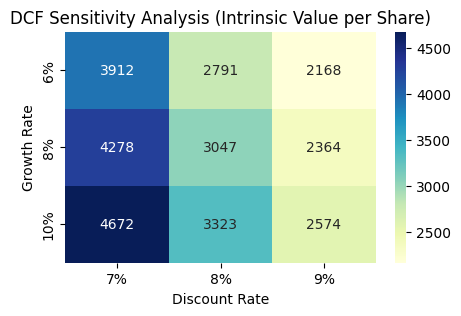

In [10]:
# Sensitivity Analysis
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("DCF Sensitivity Analysis (Intrinsic Value per Share)")
plt.xlabel("Discount Rate")
plt.ylabel("Growth Rate")

plt.show()

The intrinsic value of the stock ranges from ₹2168 to ₹4672 under different assumptions, all below the market price, which implies consistent overvaluation under current assumption.

In [12]:
# Monte Carlo Simulation
import numpy as np 
simulations = 100000
results = [] 
market_price=5701.55
for _ in range(simulations): 
    g = np.random.uniform(0.06, 0.10) 
    r = np.random.uniform(0.07, 0.09) 
    val = dcf_valuation(fcf, g, r, 0.045) 
    stock_value = val / shares_outstanding 
    results.append(stock_value)

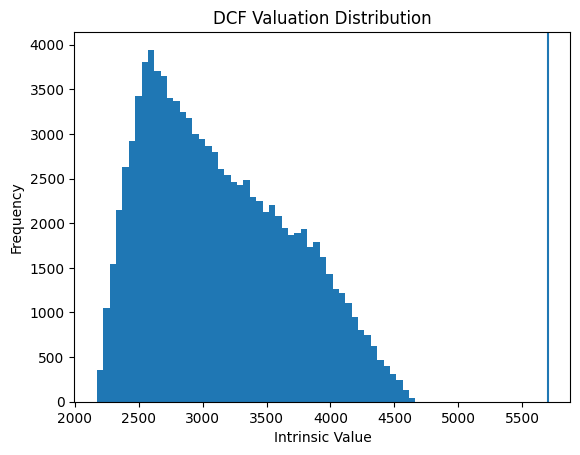

In [13]:
# Histogram of instrinsic values, derived from Monte Carlo Simulation
plt.hist(results, bins=50)
plt.axvline(market_price)
plt.title("DCF Valuation Distribution")
plt.xlabel("Intrinsic Value")
plt.ylabel("Frequency")
plt.show()

In [14]:
# Results & Interpretation
results=np.array(results)
prob_undervalue = (results > market_price).mean()
print("Probability of the stock being under valued is", prob_undervalue)
print("Probability of the stock being over valued is", 1-prob_undervalue)
print("Mean of all Intrinsic Values obtained by Monte Carlo Simulation is", np.mean(results))
# Result: 0.0 → Stock appears overvalued under all simulated scenarios

Probability of the stock being under valued is 0.0
Probability of the stock being over valued is 1.0
Mean of all Intrinsic Values obtained by Monte Carlo Simulation is 3136.726023631772


Monte Carlo simulation and sensitivity analysis both indicate intrinsic value significantly below market price.
Under reasonable assumptions, the stock appears overvalued.
This suggests market expectations may be higher than modeled growth and risk assumptions.